# Maternal Health Risk Dataset Preprocessing

This notebook prepares the maternal health dataset for model development.  
The workflow covers initial inspection, duplicate analysis, data-quality checks, abnormal-value review, outlier inspection, and analysis of conflicting target labels.

In [1]:
import pandas as pd

df = pd.read_csv("../dataset/Maternal Health Risk Data Set.csv")

df.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


#### 1. Initial Dataset Inspection

Check the dataset dimensions, column names, data types, and general structure before making any preprocessing decisions.


In [2]:
df.shape

(1014, 7)

In [3]:
df.columns

Index(['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate',
       'RiskLevel'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


#### 2. Duplicate Analysis

Identify exact duplicate rows and quantify how much of the original dataset they represent.  
The following cells also investigate whether identical feature combinations can be associated with different `RiskLevel` labels.


In [5]:
df.duplicated().sum()

np.int64(562)

In [6]:
df[df.duplicated(keep=False)].sort_values(
    by=['Age', 'SystolicBP', 'DiastolicBP']
).head(20)

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
670,10,100,50,6.0,99.0,70,mid risk
849,10,100,50,6.0,99.0,70,mid risk
171,12,90,60,7.9,102.0,66,high risk
267,12,90,60,8.0,102.0,66,high risk
276,12,90,60,11.0,102.0,60,high risk
543,12,90,60,7.5,102.0,66,low risk
552,12,90,60,7.5,102.0,60,low risk
588,12,90,60,7.5,102.0,66,mid risk
827,12,90,60,7.5,102.0,66,mid risk
934,12,90,60,7.5,102.0,66,low risk


In [7]:
duplicate_count = df.duplicated().sum()
duplicate_percentage = (duplicate_count / len(df)) * 100

print("Duplicate rows:", duplicate_count)
print("Duplicate percentage:", duplicate_percentage)

Duplicate rows: 562
Duplicate percentage: 55.42406311637082


In [8]:
duplicate_rows = df[df.duplicated(keep=False)]

duplicate_rows.groupby(
    ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']
)['RiskLevel'].nunique().value_counts()

RiskLevel
1    261
2     20
3      1
Name: count, dtype: int64

In [9]:
conflicting_rows = (
    df.groupby(
        ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']
    )['RiskLevel']
    .nunique()
)

print("Conflicting feature combinations:", (conflicting_rows > 1).sum())

Conflicting feature combinations: 35


In [10]:
# Show duplicated rows
duplicates = df[df.duplicated(keep=False)].sort_values(
    by=list(df.columns)
)

duplicates.head(20)

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
670,10,100,50,6.0,99.0,70,mid risk
849,10,100,50,6.0,99.0,70,mid risk
552,12,90,60,7.5,102.0,60,low risk
940,12,90,60,7.5,102.0,60,low risk
543,12,90,60,7.5,102.0,66,low risk
934,12,90,60,7.5,102.0,66,low risk
588,12,90,60,7.5,102.0,66,mid risk
827,12,90,60,7.5,102.0,66,mid risk
171,12,90,60,7.9,102.0,66,high risk
963,12,90,60,7.9,102.0,66,high risk


In [11]:
# Find feature combinations that have more than one RiskLevel
feature_cols = [
    "Age",
    "SystolicBP",
    "DiastolicBP",
    "BS",
    "BodyTemp",
    "HeartRate"
]

conflicts = (
    df.groupby(feature_cols)["RiskLevel"]
      .nunique()
      .reset_index(name="n_risk_levels")
)

conflicts = conflicts[conflicts["n_risk_levels"] > 1]

conflicts

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,n_risk_levels
4,12,90,60,7.5,102.0,66,2
11,12,95,60,6.9,98.0,65,2
22,13,90,65,7.5,101.0,80,2
53,15,120,80,7.5,98.0,70,2
59,16,100,70,6.9,98.0,80,2
68,17,85,60,9.0,102.0,86,2
79,17,90,65,7.5,103.0,67,2
90,18,90,60,6.9,98.0,70,2
104,19,120,75,6.9,98.0,66,2
109,19,120,80,7.0,98.0,70,2


In [12]:
# Show the actual RiskLevel values for each conflicting combination

conflicts_with_labels = (
    df.groupby(feature_cols)["RiskLevel"]
      .agg(["nunique", lambda x: list(x.unique())])
      .reset_index()
)

conflicts_with_labels.columns = feature_cols + ["n_risk_levels", "risk_levels"]

conflicts_with_labels = conflicts_with_labels[
    conflicts_with_labels["n_risk_levels"] > 1
]

conflicts_with_labels

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,n_risk_levels,risk_levels
4,12,90,60,7.5,102.0,66,2,"[low risk, mid risk]"
11,12,95,60,6.9,98.0,65,2,"[mid risk, low risk]"
22,13,90,65,7.5,101.0,80,2,"[low risk, high risk]"
53,15,120,80,7.5,98.0,70,2,"[mid risk, low risk]"
59,16,100,70,6.9,98.0,80,2,"[mid risk, low risk]"
68,17,85,60,9.0,102.0,86,2,"[mid risk, high risk]"
79,17,90,65,7.5,103.0,67,2,"[low risk, mid risk]"
90,18,90,60,6.9,98.0,70,2,"[mid risk, low risk]"
104,19,120,75,6.9,98.0,66,2,"[mid risk, low risk]"
109,19,120,80,7.0,98.0,70,2,"[mid risk, low risk]"


#### 3. Remove Exact Duplicates

Exact duplicate rows contain the same feature values **and** the same target label.  
These are removed to avoid repeated observations influencing model training and evaluation.


In [13]:
print("Before removing exact duplicates:", df.shape)

exact_duplicates = df.duplicated().sum()

print("Exact duplicate rows:", exact_duplicates)

Before removing exact duplicates: (1014, 7)
Exact duplicate rows: 562


In [14]:
df_clean = df.drop_duplicates().copy()

print("After removing exact duplicates:", df_clean.shape)

After removing exact duplicates: (452, 7)


In [15]:
print("Remaining exact duplicates:", df_clean.duplicated().sum())

Remaining exact duplicates: 0


#### 4. Initial Target-Class Distribution

Inspect the distribution of `RiskLevel` classes to understand whether the dataset is imbalanced.

> These cells use the original `df`. A final class-distribution summary using `df_clean` is provided at the end of the notebook.


In [16]:
df["RiskLevel"].value_counts()

RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64

In [17]:
df["RiskLevel"].value_counts(normalize=True).round(3)

RiskLevel
low risk     0.400
mid risk     0.331
high risk    0.268
Name: proportion, dtype: float64

#### 5. Descriptive Statistics and Missing-Value Checks

Review summary statistics, dataset size after duplicate removal, and missing-value counts before checking individual variables for unusual values.


In [18]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,452.0,29.194690,13.767379,10.0,19.0,25.0,35.0,70.0
SystolicBP,452.0,110.553097,17.872282,70.0,90.0,120.0,120.0,160.0
DiastolicBP,452.0,75.418142,13.754578,49.0,65.0,80.0,86.0,100.0
BS,452.0,8.346173,2.829209,6.0,6.9,7.5,7.9,19.0
BodyTemp,452.0,98.692478,1.410897,98.0,98.0,98.0,98.0,103.0
HeartRate,452.0,73.949115,8.156973,7.0,70.0,76.0,80.0,90.0


In [19]:
df_clean.shape

(452, 7)

In [20]:
df_clean.isnull().sum()

Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64

In [21]:
df_clean.isnull().mean() * 100

Age            0.0
SystolicBP     0.0
DiastolicBP    0.0
BS             0.0
BodyTemp       0.0
HeartRate      0.0
RiskLevel      0.0
dtype: float64

#### 6. Review Potentially Abnormal Clinical Values

Inspect unusually low or high values in key clinical features such as heart rate, blood sugar, and body temperature.  
These checks help distinguish potentially invalid observations from legitimate extreme values.


In [22]:
df_clean[df_clean["HeartRate"] < 40]

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
499,16,120,75,7.9,98.0,7,low risk


In [23]:
df_clean[df_clean["BS"] > 20]

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel


In [24]:
df_clean[df_clean["BodyTemp"] > 104]

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel


##### 6.1 Investigation of the Abnormal Heart-Rate Observation

The following cells inspect the identified observation in both the original and cleaned data, including its `RiskLevel`, before the row is removed.


In [25]:
df.loc[499]

Age                  16
SystolicBP          120
DiastolicBP          75
BS                  7.9
BodyTemp           98.0
HeartRate             7
RiskLevel      low risk
Name: 499, dtype: object

In [26]:
df_clean.loc[499]

Age                  16
SystolicBP          120
DiastolicBP          75
BS                  7.9
BodyTemp           98.0
HeartRate             7
RiskLevel      low risk
Name: 499, dtype: object

In [27]:
df_clean.loc[499, "RiskLevel"]

'low risk'

##### 6.2 Remove the Identified Abnormal Observation

The row identified above is removed from `df_clean`. The removal is related to the low heart-rate value.


In [28]:
df_clean = df_clean.drop(index=499).copy()

#### 7. Post-Cleaning Verification and Outlier Review

Verify the dataset after removal of the abnormal observation, inspect feature-value frequencies, and use the IQR method to identify statistical outliers.

> Statistical outliers are inspected rather than automatically removed, because clinically unusual values are not necessarily data errors.


In [29]:
print(df_clean.shape)
print(df_clean["HeartRate"].min())

(451, 7)
60


In [30]:
df_clean["HeartRate"].sort_values().head(10)

705    60
402    60
632    60
408    60
409    60
562    60
410    60
424    60
430    60
41     60
Name: HeartRate, dtype: int64

In [31]:
for col in df_clean.columns:
    if col != "RiskLevel":
        print(f"\n{col}")
        print(df_clean[col].value_counts().sort_index())


Age
Age
10     3
12    21
13     5
14     1
15    31
16     6
17    28
18    10
19    20
20    10
21    22
22    26
23    34
24     1
25    28
26     1
27     4
28    13
29    14
30    13
31     3
32    15
33     2
34     3
35    28
36     2
37     1
38     1
39     2
40    12
41     1
42    10
43     3
44     1
45     6
46     1
48     4
49     5
50    15
51     1
54     2
55    17
56     1
59     1
60    16
62     1
63     1
65     3
66     1
70     1
Name: count, dtype: int64

SystolicBP
SystolicBP
70       4
75       5
76       6
78       1
80       3
83       1
85      19
90      79
95       8
99       1
100     57
110     10
115      3
120    187
129      1
130     21
135      2
140     42
160      1
Name: count, dtype: int64

DiastolicBP
DiastolicBP
49     13
50     14
60     78
63      3
65     44
68      1
69      1
70     46
75     18
76      2
80     94
85     24
89      1
90     70
95     12
100    30
Name: count, dtype: int64

BS
BS
6.00     10
6.10     17
6.30      1
6.4

In [32]:
numeric_cols = [
    "Age",
    "SystolicBP",
    "DiastolicBP",
    "BS",
    "BodyTemp",
    "HeartRate"
]

Q1 = df_clean[numeric_cols].quantile(0.25)
Q3 = df_clean[numeric_cols].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_counts = (
    (df_clean[numeric_cols] < lower_bound) |
    (df_clean[numeric_cols] > upper_bound)
).sum()

outlier_counts

Age            23
SystolicBP      0
DiastolicBP     0
BS             71
BodyTemp       98
HeartRate       0
dtype: int64

#### 8. Feature Patterns by Risk Level

Compare mean and median feature values across risk classes to better understand how the predictors vary with `RiskLevel`.


In [33]:
df_clean.groupby("RiskLevel")[numeric_cols].mean().round(2)

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
RiskLevel,,,,,,
high risk,33.73,119.49,81.54,11.17,99.23,76.48
low risk,27.37,105.37,72.72,7.20,98.36,73.04
mid risk,28.54,112.41,74.89,7.89,98.86,73.90


In [34]:
df_clean.groupby("RiskLevel")[numeric_cols].median().round(2)

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
RiskLevel,,,,,,
high risk,33.5,120.0,80.0,11.0,98.0,77.0
low risk,22.0,100.0,75.0,7.2,98.0,70.0
mid risk,25.5,120.0,77.5,7.0,98.0,76.0


#### 9. Conflicting Target-Label Analysis After Cleaning

Re-check whether identical combinations of the six predictor variables are associated with more than one `RiskLevel` after preprocessing.

This is different from an exact duplicate: the predictors are identical, but the target labels disagree. The following cells quantify both the number of conflicting feature combinations and the number of affected rows.


In [35]:
feature_cols = [
    "Age",
    "SystolicBP",
    "DiastolicBP",
    "BS",
    "BodyTemp",
    "HeartRate"
]

conflicts = (
    df_clean.groupby(feature_cols)["RiskLevel"]
    .nunique()
    .reset_index(name="n_risk_levels")
)

conflicts = conflicts[conflicts["n_risk_levels"] > 1]

print("Conflicting combinations:", len(conflicts))

conflicts

Conflicting combinations: 35


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,n_risk_levels
4,12,90,60,7.5,102.0,66,2
11,12,95,60,6.9,98.0,65,2
22,13,90,65,7.5,101.0,80,2
53,15,120,80,7.5,98.0,70,2
59,16,100,70,6.9,98.0,80,2
67,17,85,60,9.0,102.0,86,2
78,17,90,65,7.5,103.0,67,2
89,18,90,60,6.9,98.0,70,2
103,19,120,75,6.9,98.0,66,2
108,19,120,80,7.0,98.0,70,2


In [36]:
conflict_details = (
    df_clean.groupby(feature_cols)["RiskLevel"]
    .agg(
        n_risk_levels="nunique",
        risk_levels=lambda x: list(x.unique()),
        n_rows="size"
    )
    .reset_index()
)

conflict_details = conflict_details[
    conflict_details["n_risk_levels"] > 1
]

conflict_details

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,n_risk_levels,risk_levels,n_rows
4,12,90,60,7.5,102.0,66,2,"[low risk, mid risk]",2
11,12,95,60,6.9,98.0,65,2,"[mid risk, low risk]",2
22,13,90,65,7.5,101.0,80,2,"[low risk, high risk]",2
53,15,120,80,7.5,98.0,70,2,"[mid risk, low risk]",2
59,16,100,70,6.9,98.0,80,2,"[mid risk, low risk]",2
67,17,85,60,9.0,102.0,86,2,"[mid risk, high risk]",2
78,17,90,65,7.5,103.0,67,2,"[low risk, mid risk]",2
89,18,90,60,6.9,98.0,70,2,"[mid risk, low risk]",2
103,19,120,75,6.9,98.0,66,2,"[mid risk, low risk]",2
108,19,120,80,7.0,98.0,70,2,"[mid risk, low risk]",2


In [37]:
conflicting = (
    df_clean
    .groupby(['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate'])
    ['RiskLevel']
    .nunique()
)

conflicting = conflicting[conflicting > 1]

print("Conflicting feature combinations:", len(conflicting))

Conflicting feature combinations: 35


In [38]:
feature_cols = [
    'Age',
    'SystolicBP',
    'DiastolicBP',
    'BS',
    'BodyTemp',
    'HeartRate'
]

conflicting_rows = (
    df_clean
    .groupby(feature_cols)
    .filter(lambda x: x['RiskLevel'].nunique() > 1)
)

print(conflicting_rows.shape)

(71, 7)


In [39]:
conflicting_rows['RiskLevel'].value_counts()

RiskLevel
low risk     30
mid risk     30
high risk    11
Name: count, dtype: int64

#### **Decision on Conflicting Labels**

**How to solve this?**
We identified 35 conflicting groups affecting 71 rows.
The correct label cannot be determined directly from this dataset.

**Our Options:**
1. Remove them to avoid introducing uncertain labels.
2. Resolve the conflicts using a medically justified rule (better to flag questionable case than miss a truly high-risk one).
3. Keep the conflicting rows as they are and make the model more sensitive to high-risk cases, prioritizing high recall and minimizing false negatives.

**Decision:** Pending discussion with the team.

In [ ]:
# reminder to save the final cleaned dataset after decison is made 

## **10. Final Preprocessing Summary**

This section provides a concise end-of-notebook summary so the preprocessing outcome can be reviewed without reading every intermediate cell.


In [43]:
# ========== FINAL SUMMARY ==========
print("Final shape:", df_clean.shape)
print("Missing values:", df_clean.isnull().sum().sum())
print("Duplicate rows:", df_clean.duplicated().sum())

print("\nClass distribution:")
print(df_clean["RiskLevel"].value_counts())

print("\nClass percentages:")
print(df_clean["RiskLevel"].value_counts(normalize=True).round(3) * 100)



Final shape: (451, 7)
Missing values: 0
Duplicate rows: 0

Class distribution:
RiskLevel
low risk     233
high risk    112
mid risk     106
Name: count, dtype: int64

Class percentages:
RiskLevel
low risk     51.7
high risk    24.8
mid risk     23.5
Name: proportion, dtype: float64


#### 11. Preprocessing Visualizations

The following plots summarize the two preprocessing results most useful for presentation:

1. **How the dataset size changed during preprocessing**
2. **The final class distribution after preprocessing**

The plots are generated dynamically from `df` and `df_clean`, so they reflect the current notebook results when run.


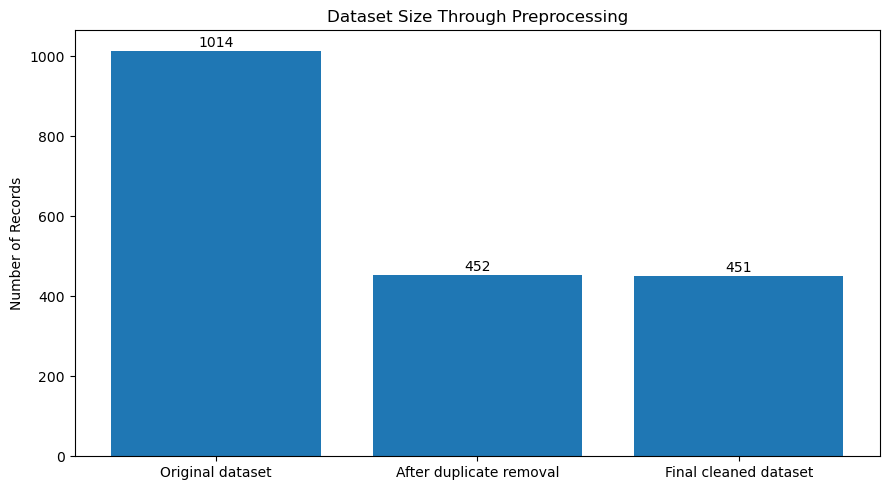

In [48]:
import matplotlib.pyplot as plt

##  1. Dataset size through preprocessing
original_rows = len(df)
exact_duplicates = df.duplicated().sum()
after_duplicates = original_rows - exact_duplicates
final_rows = len(df_clean)

preprocessing_stages = [
    "Original dataset",
    "After duplicate removal",
    "Final cleaned dataset"
]

row_counts = [
    original_rows,
    after_duplicates,
    final_rows
]

plt.figure(figsize=(9, 5))
bars = plt.bar(preprocessing_stages, row_counts)

plt.title("Dataset Size Through Preprocessing")
plt.ylabel("Number of Records")

for bar, count in zip(bars, row_counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(row_counts) * 0.01,
        f"{count}",
        ha="center"
    )

plt.tight_layout()
plt.show()


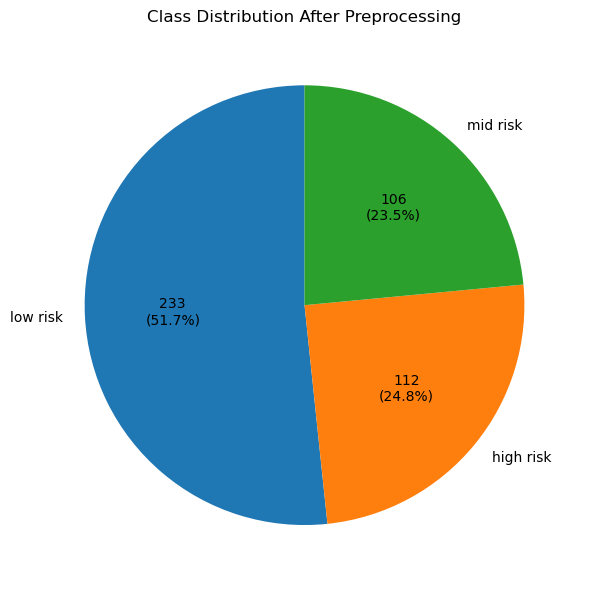

In [ ]:
## 2. Final RiskLevel distribution after preprocessing
class_counts = df_clean["RiskLevel"].value_counts()

def count_and_percentage(pct):
    total = class_counts.sum()
    count = int(round(pct * total / 100))
    return f"{count}\n({pct:.1f}%)"

plt.figure(figsize=(7, 6))

plt.pie(
    class_counts.values,
    labels=class_counts.index,
    autopct=count_and_percentage,
    startangle=90
)

plt.title("Class Distribution After Preprocessing")

plt.tight_layout()
plt.show()


This chart presents the class balance **after preprocessing** using `df_clean`.  
Both the number of records and percentage of the cleaned dataset are shown for each risk class.
